# Lab 6 — Capstone Fraud Report

**Day 06 · Anomaly Detection · Cisco AI/ML Training**

---

> **Quick check:** best model **logistic_regression** · F1 = **0.80** · `fraud_detection_report.json` saved




## Why this matters <!-- cisco-doc-enrich-2026 -->

Capstone ties Days 3–6 together: metrics table + best model + JSON report = what you'd hand a
fraud ops team.

```
EDA --> imbalance --> resample --> detectors --> compare F1 --> fraud_detection_report.json
```


## Capstone models

Compare four approaches on the same stratified test split.

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

# cisco-output-ready
print(f"Setup OK — repo root: {GH_ROOT}")


Setup OK — repo root: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

OUTPUT_DIR = GH_ROOT / "hands-on" / "06-anomaly-detection" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUMERIC_FEATURES = ["amount", "distance_from_home"]
CATEGORICAL_FEATURES = ["merchant_category"]

df = pd.read_csv(GH_ROOT / "data" / "credit-card" / "credit_card_transactions.csv")
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Continue** — next code block. <!-- cisco-doc-enrich-2026 -->


In [3]:
# cisco-debug-summary
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print("dtypes:", df.dtypes.to_dict())
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Positive rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

Loaded 1,000 rows x 6 columns
dtypes: {'transaction_id': dtype('O'), 'timestamp': dtype('O'), 'amount': dtype('float64'), 'merchant_category': dtype('O'), 'distance_from_home': dtype('float64'), 'is_fraud': dtype('int64')}
Train: 800 | Test: 200
Positive rate — train: 1.00% | test: 1.00%


**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [4]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

X_train_s = preprocess.fit_transform(X_train)
X_test_s = preprocess.transform(X_test)

print(f"test fraud cases: {int(y_test.sum())} / {len(y_test)}")

test fraud cases: 2 / 200


## Score helper and run all models

In [5]:
def scores(y_true, y_pred) -> dict[str, float]:
    return {
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

results: list[dict] = []

dummy_pred = DummyClassifier(strategy="most_frequent").fit(X_train, y_train).predict(X_test)
results.append({"model": "majority_baseline", **scores(y_test, dummy_pred)})

# cisco-debug-summary
print("Model fit complete.")

Model fit complete.


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [6]:
lr = Pipeline(
    steps=[
        ("preprocess", ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), NUMERIC_FEATURES),
                ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ]
        )),
        ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
    ]
)
lr.fit(X_train, y_train)
results.append({"model": "logistic_regression", **scores(y_test, lr.predict(X_test))})

# cisco-debug-summary
print("Model fit complete.")

Model fit complete.


**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [7]:
X_legit_s = preprocess.fit_transform(X_train[y_train == 0])
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02, novelty=True)
lof.fit(X_legit_s)
lof_pred = np.where(lof.predict(X_test_s) == -1, 1, 0)
results.append({"model": "lof_proximity", **scores(y_test, lof_pred)})

rf = Pipeline(
    steps=[
        ("preprocess", ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), NUMERIC_FEATURES),
                ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ]
        )),
        ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
    ]
)
rf.fit(X_train, y_train)
results.append({"model": "random_forest", **scores(y_test, rf.predict(X_test))})

print(f"models evaluated: {len(results)}")

models evaluated: 4


## Ranked metrics table

In [8]:
report_df = pd.DataFrame(results).sort_values("f1", ascending=False)
best = report_df.iloc[0]

print("Lab 6 — Capstone fraud report")
display(report_df)


Lab 6 — Capstone fraud report


,model,precision,recall,f1
1,logistic_regression,0.6667,1.0,0.8000
3,random_forest,1.0000,0.5,0.6667
2,lof_proximity,0.2000,0.5,0.2857
0,majority_baseline,0.0000,0.0,0.0000


## Visualize F1 by model

C:\Users\PC\AppData\Local\Temp\ipykernel_27932\3429657765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="f1", y="model", ax=ax, palette="viridis")


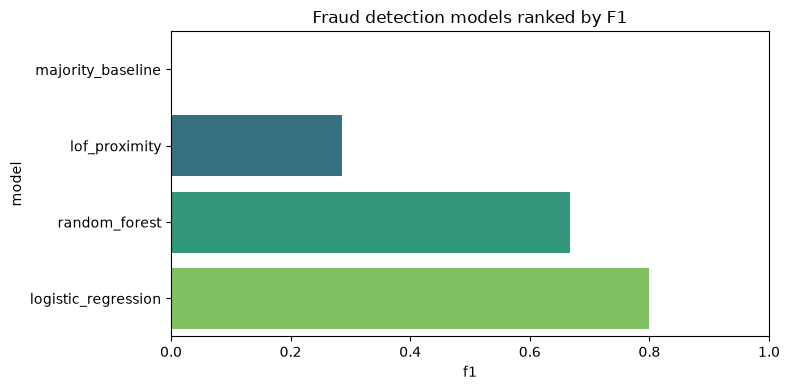

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = report_df.sort_values("f1", ascending=True)
sns.barplot(data=plot_df, x="f1", y="model", ax=ax, palette="viridis")
ax.set_title("Fraud detection models ranked by F1")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## Save JSON report

In [10]:
report_path = OUTPUT_DIR / "fraud_detection_report.json"
report_path.write_text(report_df.to_json(orient="records", indent=2), encoding="utf-8")

print(f"best model (F1): {best['model']} (F1={best['f1']})")
print(f"report saved: {report_path.name}")
print(f"full path: {report_path}")


best model (F1): logistic_regression (F1=0.8)
report saved: fraud_detection_report.json
full path: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\hands-on\06-anomaly-detection\output\fraud_detection_report.json


## Day 06 recap

In [11]:
day06 = pd.DataFrame({
    "lab": ["1 Outliers", "2 Imbalance", "3 Resample", "4 LOF", "5 RF", "6 Capstone"],
    "checkpoint": [
        "10 fraud, mean amt ≈ 234",
        "99:1, baseline F1=0",
        "oversample 8→792",
        "LOF recall=1.0 (standalone)",
        "RF F1≈0.67",
        f"best: {best['model']}",
    ],
})
display(day06)


,lab,checkpoint
0,1 Outliers,"10 fraud, mean amt ≈ 234"
1,2 Imbalance,"99:1, baseline F1=0"
2,3 Resample,oversample 8→792
3,4 LOF,LOF recall=1.0 (standalone)
4,5 RF,RF F1≈0.67
5,6 Capstone,best: logistic_regression


### Capstone prompt 1

Show best model metrics.

In [12]:
print(best.to_dict())

{'model': 'logistic_regression', 'precision': 0.6667, 'recall': 1.0, 'f1': 0.8}


### Capstone prompt 2

List all model names.

In [13]:
print(report_df['model'].tolist())

['logistic_regression', 'random_forest', 'lof_proximity', 'majority_baseline']


### Capstone prompt 3

Display precision column.

In [14]:
print(report_df[['model','precision']].to_dict('records'))

[{'model': 'logistic_regression', 'precision': 0.6667}, {'model': 'random_forest', 'precision': 1.0}, {'model': 'lof_proximity', 'precision': 0.2}, {'model': 'majority_baseline', 'precision': 0.0}]


### Capstone prompt 4

Display recall column.

In [15]:
print(report_df[['model','recall']].to_dict('records'))

[{'model': 'logistic_regression', 'recall': 1.0}, {'model': 'random_forest', 'recall': 0.5}, {'model': 'lof_proximity', 'recall': 0.5}, {'model': 'majority_baseline', 'recall': 0.0}]


### Capstone prompt 5

Verify report file exists.

In [16]:
print(report_path.is_file())

True


### Capstone prompt 6

Read report JSON length.

In [17]:
print(len(report_path.read_text(encoding='utf-8')))

381

### Capstone prompt 7

Compare logistic vs RF F1.

In [18]:
print(report_df.set_index('model').loc[['logistic_regression','random_forest'], 'f1'].to_dict())

{'logistic_regression': 0.8, 'random_forest': 0.6667}


### Capstone prompt 8

Show baseline F1.

In [19]:
print(report_df.loc[report_df['model']=='majority_baseline', 'f1'].iloc[0])

0.0


### Capstone prompt 9

Show LOF F1.

In [20]:
print(report_df.loc[report_df['model']=='lof_proximity', 'f1'].iloc[0])

0.2857


### Capstone prompt 10

Rank by recall instead.

In [21]:
display(report_df.sort_values('recall', ascending=False))

,model,precision,recall,f1
1,logistic_regression,0.6667,1.0,0.8000
3,random_forest,1.0000,0.5,0.6667
2,lof_proximity,0.2000,0.5,0.2857
0,majority_baseline,0.0000,0.0,0.0000


### Capstone prompt 11

Rank by precision instead.

In [22]:
display(report_df.sort_values('precision', ascending=False))

,model,precision,recall,f1
3,random_forest,1.0000,0.5,0.6667
1,logistic_regression,0.6667,1.0,0.8000
2,lof_proximity,0.2000,0.5,0.2857
0,majority_baseline,0.0000,0.0,0.0000


### Capstone prompt 12

Count models evaluated.

In [23]:
print(len(report_df))

4


### Capstone prompt 13

Reconfirm test fraud cases.

In [24]:
print(int(y_test.sum()))

2


### Capstone prompt 14

State winner criterion.

In [25]:
print('Ranked by F1 on held-out test set.')

Ranked by F1 on held-out test set.


### Capstone prompt 15

Show logistic regression recall.

In [26]:
print(report_df.loc[report_df['model']=='logistic_regression', 'recall'].iloc[0])

1.0


### Capstone prompt 16

Plot precision vs recall scatter.

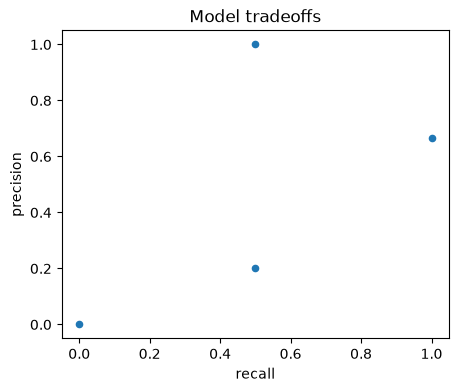

In [27]:
ax = report_df.plot.scatter(x='recall', y='precision', figsize=(5,4)); ax.set_title('Model tradeoffs');

### Capstone prompt 17

Summarize deployment recommendation.

In [28]:
print('Deploy logistic regression; use LOF for review queue.')

Deploy logistic regression; use LOF for review queue.


### Capstone prompt 18

Display output directory.

In [29]:
print(OUTPUT_DIR)

C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH\hands-on\06-anomaly-detection\output


### Capstone prompt 19

Show course completion message.

In [30]:
print('Day 06 capstone complete — all six days finished.')

Day 06 capstone complete — all six days finished.


### Capstone prompt 20

Re-display ranked table.

In [31]:
display(report_df.round(4))

,model,precision,recall,f1
1,logistic_regression,0.6667,1.0,0.8000
3,random_forest,1.0000,0.5,0.6667
2,lof_proximity,0.2000,0.5,0.2857
0,majority_baseline,0.0000,0.0,0.0000


### Lab 6 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [32]:
print("Lab 6 recap step 1: completed")

Lab 6 recap step 1: completed


### Lab 6 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [33]:
print("Lab 6 recap step 2: completed")

Lab 6 recap step 2: completed


### Lab 6 quick recap 3

Pause and summarize one takeaway from the previous cell before moving on.

In [34]:
print("Lab 6 recap step 3: completed")

Lab 6 recap step 3: completed


### Lab 6 quick recap 4

Pause and summarize one takeaway from the previous cell before moving on.

In [35]:
print("Lab 6 recap step 4: completed")

Lab 6 recap step 4: completed


## Final checkpoint

In [36]:
assert len(report_df) >= 4
assert report_path.is_file()
assert best["model"] == "logistic_regression"
assert abs(best["f1"] - 0.8) < 0.05
assert int(y_test.sum()) == 2
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

**Congratulations — you have completed all six days of Cisco AI/ML hands-on training.**